In [1]:
import pandas as pd
import numpy as np
import logging
import penaltyblog as pb

In [2]:
import sys
sys.path.insert(0, '../src')
from dixon_coles import create_model, create_team_ratings

[02/24/26 10:50:29] INFO     No custom team name replacements found. You can configure these in       ]8;id=778536;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=697083;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/soccerdata/_config.py#92\92]8;;\
                             /Users/jaakkotoivonen/soccerdata/config/teamname_replacements.json.                   

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=34481;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/soccerdata/_config.py\_config.py]8;;\:]8;id=744808;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/soccerdata/_config.py#198\198]8;;\
                             /Users/jaakkotoivonen/soccerdata/config/league_dict.json.                             

## Functions

In [3]:
def fit_models_by_group(grouped_data, args, export_ratings=False):
    """
    Fit Dixon-Coles models for each group (season, league_division, and group combination)
    and create team ratings for each group.
    
    Parameters:
    -----------
    grouped_data : pd.GroupBy object
        Grouped data with groups defined by season, league_division, and group
    args : argparse.Namespace
        Arguments object containing configuration (e.g., league, save options)
    export_ratings : bool
        Whether to export ratings as images (default: False)
    
    Returns:
    --------
    all_ratings_df : pd.DataFrame
        DataFrame containing team ratings for all groups with columns:
        ['group_key', 'season', 'league_division', 'group', 'team', 'attack_rating', 
         'defense_rating', 'goal_difference_rating']
    models_dict : dict
        Dictionary containing fitted models for each group, keyed by group_key
    
    Usage Example:
    --------------
    grouped = matches.groupby(['season', 'league_division', 'group'])
    all_ratings_df, models_dict = fit_models_by_group(grouped, args)
    print(all_ratings_df)
    
    # Access a specific model
    specific_model = models_dict[(2025, 6, 'A')]  # Model for season 2025, division 6, group A
    
    # View ratings for a specific season, division, and group
    ratings_2025_div6_groupA = all_ratings_df[
        (all_ratings_df['season'] == 2025) & 
        (all_ratings_df['league_division'] == 6) &
        (all_ratings_df['group'] == 'A')
    ]
    print(ratings_2025_div6_groupA)
    """
    
    all_ratings = []
    models_dict = {}
    failed_groups = {}
    
    logging.info("Starting to fit models for each group...")
    
    for group_key, group_data in grouped_data:
        logging.info(f"Processing group: {group_key}")
        
        # Extract season, league_division, and group from group_key (assuming it's a tuple)
        if isinstance(group_key, tuple):
            season, league_division, group = group_key
        else:
            season = group_key
            league_division = None
            group = None
        
        # Prepare data for model fitting
        df = group_data.copy()
        
        # Ensure required columns exist
        if 'goals_home' not in df.columns or 'goals_away' not in df.columns:
            logging.warning(f"Skipping group {group_key}: missing goals_home or goals_away columns")
            continue
        
        if 'team_home' not in df.columns or 'team_away' not in df.columns:
            logging.warning(f"Skipping group {group_key}: missing team_home or team_away columns")
            continue
        
        # Get unique teams in this group
        teams = np.sort(pd.concat([df['team_home'], df['team_away']]).unique())
        
        if len(teams) < 2:
            logging.warning(f"Skipping group {group_key}: insufficient number of teams ({len(teams)})")
            continue
        
        try:
            # Create and fit the model using imported function
            logging.info(f"Creating Dixon-Coles model for {group_key}...")

            clf = pb.models.DixonColesGoalModel(
                df["goals_home"], df["goals_away"], df["team_home"], df["team_away"]
            )
            clf.fit()
            
            # Make predictions for each game in the group
            logging.info(f"Making predictions for group {group_key}...")
            for _, row in df.iterrows():
                home_team = row['team_home']
                away_team = row['team_away']
                
                # Get prediction object
                probs = clf.predict(home_team, away_team)
                
                # Extract outcome probabilities (home_win, draw, away_win)
                home_win_prob = probs.home_win
                draw_prob = probs.draw
                away_win_prob = probs.away_win
                outcome_probs = [home_win_prob, draw_prob, away_win_prob]
                
                # Assert probabilities are valid
                assert all(0 <= p <= 1 for p in outcome_probs), f"Invalid probabilities for {home_team} vs {away_team}: {outcome_probs}"
                prob_sum = sum(outcome_probs)
                assert abs(prob_sum - 1.0) < 0.01, f"Probabilities do not sum to 1 for {home_team} vs {away_team}: {outcome_probs} (sum={prob_sum})"
            
            # Store the model
            models_dict[group_key] = clf
            
            # Create team ratings using imported function
            logging.info(f"Creating team ratings for {group_key}...")
            ratings_df = create_team_ratings(clf, teams, args, export_ratings=export_ratings)
            
            # Add group information to ratings
            ratings_df['group_key'] = str(group_key)
            ratings_df['season'] = season
            ratings_df['league_division'] = league_division
            ratings_df['group'] = group
            
            all_ratings.append(ratings_df)
            
        except Exception as e:
            logging.error(f"Error fitting model for group {group_key}: {e}")
            failed_groups[group_key] = [str(e), len(df)]
            continue
    
    # Combine all ratings into a single DataFrame
    if all_ratings:
        all_ratings_df = pd.concat(all_ratings, ignore_index=True)
    else:
        all_ratings_df = pd.DataFrame()
    
    logging.info(f"Successfully fitted models for {len(models_dict)} groups")
    logging.info(f"Total ratings created: {len(all_ratings_df)}")
    
    return all_ratings_df, models_dict, failed_groups

In [4]:
def calculate_division_change_impact(all_ratings_df):
    """
    Calculate how much a team's attacking, defensive, and goal difference ratings
    change when they move from one division to another between seasons.
    
    Parameters:
    -----------
    all_ratings_df : pd.DataFrame
        DataFrame with columns: 'season', 'league_division', 'team', 'attack_rating',
        'defense_rating', 'goal_difference_rating'
    
    Returns:
    --------
    changes_df : pd.DataFrame
        DataFrame containing rating changes for teams that changed divisions,
        with columns: ['team', 'season_from', 'season_to', 'division_from', 'division_to',
                      'attack_change', 'defense_change', 'goal_diff_change']
    
    Usage Example:
    --------------
    changes_df = calculate_division_change_impact(all_ratings_df)
    print(changes_df)
    
    # View changes for teams moving from division 6 to 7
    div_6_to_7 = changes_df[
        (changes_df['division_from'] == 6) & 
        (changes_df['division_to'] == 7)
    ]
    print(div_6_to_7)
    
    # Get average rating changes by division transition
    avg_changes = changes_df.groupby(['division_from', 'division_to']).agg({
        'attack_change': 'mean',
        'defense_change': 'mean',
        'goal_diff_change': 'mean'
    })
    print(avg_changes)
    """
    
    changes = []
    
    # Get unique seasons and sort them
    seasons = sorted(all_ratings_df['season'].unique())
    
    if len(seasons) < 2:
        logging.warning("Not enough seasons to calculate division changes")
        return pd.DataFrame()
    
    # For each consecutive pair of seasons
    for i in range(len(seasons) - 1):
        season_from = seasons[i]
        season_to = seasons[i + 1]
        
        logging.info(f"Processing division changes from season {season_from} to {season_to}")
        
        # Get ratings for current and next season
        ratings_from = all_ratings_df[all_ratings_df['season'] == season_from].copy()
        ratings_to = all_ratings_df[all_ratings_df['season'] == season_to].copy()
        
        # Get unique teams in each season
        teams_from = set(ratings_from['team'].unique())
        teams_to = set(ratings_to['team'].unique())
        
        # Find teams that exist in both seasons
        common_teams = teams_from & teams_to
        
        for team in common_teams:
            # Get team data for both seasons
            team_from = ratings_from[ratings_from['team'] == team]
            team_to = ratings_to[ratings_to['team'] == team]
            
            if len(team_from) == 0 or len(team_to) == 0:
                continue
            
            # Get division and ratings from previous season
            division_from = team_from['league_division'].values[0]
            attack_from = team_from['attack_rating'].values[0]
            defense_from = team_from['defense_rating'].values[0]
            goal_diff_from = team_from['goal_difference_rating'].values[0]
            
            # Get division and ratings for current season
            division_to = team_to['league_division'].values[0]
            attack_to = team_to['attack_rating'].values[0]
            defense_to = team_to['defense_rating'].values[0]
            goal_diff_to = team_to['goal_difference_rating'].values[0]
            
            # Only record if division changed
            if division_from != division_to:
                changes.append({
                    'team': team,
                    'season_from': season_from,
                    'season_to': season_to,
                    'division_from': int(division_from),
                    'division_to': int(division_to),
                    'attack_change': attack_to - attack_from,
                    'defense_change': defense_to - defense_from,
                    'goal_diff_change': goal_diff_to - goal_diff_from
                })
    
    # Convert to DataFrame
    changes_df = pd.DataFrame(changes)
    
    if len(changes_df) > 0:
        logging.info(f"Found {len(changes_df)} division changes across seasons")
    else:
        logging.warning("No division changes found")
    
    return changes_df

In [5]:
def calculate_same_division_rating_changes(all_ratings_df):
    """
    Calculate year-to-year changes in attacking, defensive, and goal difference ratings
    for teams that stayed in the same division.
    
    Parameters:
    -----------
    all_ratings_df : pd.DataFrame
        DataFrame with columns: 'season', 'league_division', 'team', 'attack_rating',
        'defense_rating', 'goal_difference_rating'
    
    Returns:
    --------
    changes_df : pd.DataFrame
        DataFrame containing rating changes for teams that stayed in the same division,
        with columns: ['team', 'season_from', 'season_to', 'division', 'attack_change',
                      'defense_change', 'goal_diff_change']
    summary_stats : pd.DataFrame
        Summary statistics (mean and std) of rating changes by division
    
    Usage Example:
    --------------
    changes_df, summary_stats = calculate_same_division_rating_changes(all_ratings_df)
    print(changes_df)
    print()
    print(summary_stats)
    
    # View changes for teams staying in division 6
    div_6_changes = changes_df[changes_df['division'] == 6]
    print(div_6_changes)
    
    # Get overall statistics
    print(summary_stats.loc['overall'])
    """
    
    import pandas as pd
    import logging
    
    changes = []
    
    # Get unique seasons and sort them
    seasons = sorted(all_ratings_df['season'].unique())
    
    if len(seasons) < 2:
        logging.warning("Not enough seasons to calculate same-division rating changes")
        return pd.DataFrame(), pd.DataFrame()
    
    # For each consecutive pair of seasons
    for i in range(len(seasons) - 1):
        season_from = seasons[i]
        season_to = seasons[i + 1]
        
        logging.info(f"Processing same-division changes from season {season_from} to {season_to}")
        
        # Get ratings for current and next season
        ratings_from = all_ratings_df[all_ratings_df['season'] == season_from].copy()
        ratings_to = all_ratings_df[all_ratings_df['season'] == season_to].copy()
        
        # Get unique teams in each season
        teams_from = set(ratings_from['team'].unique())
        teams_to = set(ratings_to['team'].unique())
        
        # Find teams that exist in both seasons
        common_teams = teams_from & teams_to
        
        for team in common_teams:
            # Get team data for both seasons
            team_from = ratings_from[ratings_from['team'] == team]
            team_to = ratings_to[ratings_to['team'] == team]
            
            if len(team_from) == 0 or len(team_to) == 0:
                continue
            
            # Get division and ratings from previous season
            division_from = team_from['league_division'].values[0]
            attack_from = team_from['attack_rating'].values[0]
            defense_from = team_from['defense_rating'].values[0]
            goal_diff_from = team_from['goal_difference_rating'].values[0]
            
            # Get division and ratings for current season
            division_to = team_to['league_division'].values[0]
            attack_to = team_to['attack_rating'].values[0]
            defense_to = team_to['defense_rating'].values[0]
            goal_diff_to = team_to['goal_difference_rating'].values[0]
            
            # Only record if division stayed the same
            if division_from == division_to:
                changes.append({
                    'team': team,
                    'season_from': season_from,
                    'season_to': season_to,
                    'division': int(division_from),
                    'attack_change': attack_to - attack_from,
                    'defense_change': defense_to - defense_from,
                    'goal_diff_change': goal_diff_to - goal_diff_from
                })
    
    # Convert to DataFrame
    changes_df = pd.DataFrame(changes)
    
    if len(changes_df) > 0:
        logging.info(f"Found {len(changes_df)} same-division observations across seasons")
    else:
        logging.warning("No same-division observations found")
        return changes_df, pd.DataFrame()
    
    # Calculate summary statistics by division
    summary_stats = changes_df.groupby('division').agg({
        'attack_change': ['mean', 'std', 'count'],
        'defense_change': ['mean', 'std'],
        'goal_diff_change': ['mean', 'std']
    }).round(4)
    
    # Add overall statistics
    overall_stats = pd.DataFrame({
        ('attack_change', 'mean'): [changes_df['attack_change'].mean()],
        ('attack_change', 'std'): [changes_df['attack_change'].std()],
        ('attack_change', 'count'): [len(changes_df)],
        ('defense_change', 'mean'): [changes_df['defense_change'].mean()],
        ('defense_change', 'std'): [changes_df['defense_change'].std()],
        ('goal_diff_change', 'mean'): [changes_df['goal_diff_change'].mean()],
        ('goal_diff_change', 'std'): [changes_df['goal_diff_change'].std()]
    }, index=['overall']).round(4)
    
    summary_stats = pd.concat([summary_stats, overall_stats])
    
    return changes_df, summary_stats

## Model each group

In [ ]:
df = pd.read_csv("../data/finland_5_6_7_divisions_results_20-25.csv")
display(df.head())
display(df.shape)

In [ ]:
grouped = df.groupby(['season', 'league_division', 'group'])

In [ ]:
all_ratings_df, models_dict, failed_groups = fit_models_by_group(grouped, args={})

In [ ]:
all_ratings_df

In [ ]:
len(models_dict)

In [ ]:
grouped.ngroups

In [ ]:
pd.DataFrame.from_dict(failed_groups, orient='index', columns=['error_message', 'num_matches'])

In [ ]:
all_ratings_df[all_ratings_df.team=='Trikiinit']

In [ ]:
changes_df = calculate_division_change_impact(all_ratings_df)
changes_df

In [ ]:
# Get average rating changes by division transition
avg_changes = changes_df.groupby(['division_from', 'division_to']).agg({
    'attack_change': 'mean',
    'defense_change': 'mean',
    'goal_diff_change': 'mean'
})

avg_changes['count'] = changes_df.groupby(['division_from', 'division_to']).size()

display(avg_changes)

In [ ]:
changes_df, summary_stats = calculate_same_division_rating_changes(all_ratings_df)
display(changes_df)
print()
display(summary_stats)

# View changes for teams staying in division 6
#div_6_changes = changes_df[changes_df['division'] == 6]
#print(div_6_changes)

# Get overall statistics
display(summary_stats.loc['overall'])

In [ ]:
changes_df['goal_diff_change'].plot(kind='hist', bins=20, title='Distribution of Goal Difference Rating Changes for Same-Division Teams')

In [ ]:
# standardizad ratings for Trikiinit across divisions over time
# aux = all_ratings_df[all_ratings_df.team=='Trikiinit'].copy()
# aux.loc[aux.league_division==7, 'attack_rating'] = aux.loc[aux.league_division==7, 'attack_rating'] + 0.117265
# aux.loc[aux.league_division==7, 'defense_rating'] = aux.loc[aux.league_division==7, 'defense_rating'] + 1.361395
# aux.loc[aux.league_division==7, 'goal_difference_rating'] = aux.loc[aux.league_division==7, 'attack_rating'] - aux.loc[aux.league_division==7, 'defense_rating']
# aux

In [ ]:
#aux.plot(x='season', y=['attack_rating', 'defense_rating'], title='Trikiinit Ratings Over Time Standardized for 6th Division Level', marker='o')

In [ ]:
#aux.plot(x='season', y=['goal_difference_rating'], title='Trikiinit Ratings Over Time Standardized for 6th Division Level', marker='o')

In [ ]:
models_dict[(np.int64(20), np.int64(5), np.float64(13.0))]

In [ ]:
aux = df[(df.season==22) & (df.league_division==6) & (df.group==4)].copy()
aux

In [ ]:
clf = pb.models.DixonColesGoalModel(
    aux["goals_home"], aux["goals_away"], aux["team_home"], aux["team_away"], 
)
clf.fit()

In [ ]:
row = aux.iloc[3]
home_team = row['team_home']
away_team = row['team_away']

# Get prediction object
probs = clf.predict(home_team, away_team)

# Extract outcome probabilities (home_win, draw, away_win)
home_win_prob = probs.home_win
draw_prob = probs.draw
away_win_prob = probs.away_win
outcome_probs = [home_win_prob, draw_prob, away_win_prob]
print(outcome_probs)
print(sum(outcome_probs))

In [ ]:
clf

# Single model

## Data

In [6]:
df = pd.read_csv("../data/finland_5_6_7_divisions_results_20-25.csv")
df

,team_home,team_away,goals_home,goals_away,league_division,season,group
0,FC HIK,PEF,3,0,5,25,1
1,FC Samba,KaPy,2,5,5,25,1
2,LoPa/2,HooGee/23,0,0,5,25,1
3,Olarin Kiksi,Hukat,6,2,5,25,1
4,HooGee/23,FC HIK,3,7,5,25,1
...,...,...,...,...,...,...,...
8857,JJ Vepo,MoPo,0,1,7,20,5
8858,KOPSE/CRPS FC,FC Puimur,1,4,7,20,5
8859,Cosmos,KOPSE/CRPS FC,3,1,7,20,5
8860,AS RaPe,KOPSE/CRPS FC,2,0,7,20,5


In [7]:
df['date'] = df.apply(lambda row: pd.to_datetime(f"01-06-{row['season']}", dayfirst=True), axis=1)
df

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
0,FC HIK,PEF,3,0,5,25,1,2025-06-01
1,FC Samba,KaPy,2,5,5,25,1,2025-06-01
2,LoPa/2,HooGee/23,0,0,5,25,1,2025-06-01
3,Olarin Kiksi,Hukat,6,2,5,25,1,2025-06-01
4,HooGee/23,FC HIK,3,7,5,25,1,2025-06-01
...,...,...,...,...,...,...,...,...
8857,JJ Vepo,MoPo,0,1,7,20,5,2020-06-01
8858,KOPSE/CRPS FC,FC Puimur,1,4,7,20,5,2020-06-01
8859,Cosmos,KOPSE/CRPS FC,3,1,7,20,5,2020-06-01
8860,AS RaPe,KOPSE/CRPS FC,2,0,7,20,5,2020-06-01


In [8]:
aux = pd.concat((df['team_home'], df['team_away']), ignore_index=True)
aux.value_counts()

Vesa/Töölö            95
HePu                  95
FC POHU/Futboleros    95
PPV                   95
PPV/Seos              94
                      ..
Kasiysi/Rocky          9
RiRa/VGS               9
FC Viikingit/B         9
Ruisku                 8
FC POHU/JäPa 2         7
Name: count, Length: 380, dtype: int64

<Axes: title={'center': 'Number of Matches per Team'}>

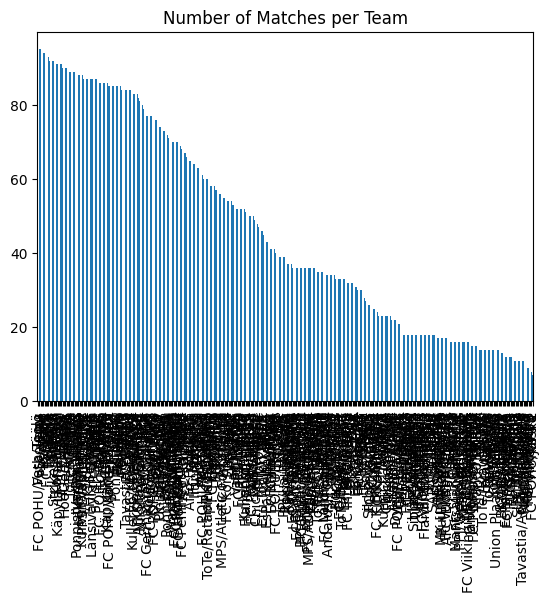

In [9]:
aux.value_counts().sort_values(ascending=False).plot(kind='bar', title='Number of Matches per Team')

## Fit model

In [10]:
xi = 0.0009
weights = pb.models.dixon_coles_weights(df["date"], xi)

clf = pb.models.DixonColesGoalModel(
        df["goals_home"], df["goals_away"], df["team_home"], df["team_away"], weights
    )
clf.fit()

In [11]:
error_count_invalid = 0
error_count_sum_not_one = 0
for _, row in df.iterrows():
    
    home_team = row['team_home']
    away_team = row['team_away']
    
    # Get prediction object
    probs = clf.predict(home_team, away_team)
    
    # Extract outcome probabilities (home_win, draw, away_win)
    home_win_prob = probs.home_win
    draw_prob = probs.draw
    away_win_prob = probs.away_win
    outcome_probs = [home_win_prob, draw_prob, away_win_prob]
    
    if not (all(0 <= p <= 1 for p in outcome_probs)):
        print(f"Invalid probabilities for {home_team} vs {away_team}: {outcome_probs}")
        error_count_invalid += 1

    prob_sum = sum(outcome_probs)
    if abs(1-prob_sum) > 0.02:
        print(f"Probabilities do not sum to 1 for {home_team} vs {away_team}: {outcome_probs} (sum={prob_sum})")
        error_count_sum_not_one += 1

print(f"Total invalid probability errors: {error_count_invalid}")
print(f"Proportion of games with invalid probabilities: {error_count_invalid / len(df):.4f}")
print(f"Total probability sum errors: {error_count_sum_not_one}")
print(f"Proportion of games with probability sum errors: {error_count_sum_not_one / len(df):.4f}")

Probabilities do not sum to 1 for LPS/reservi vs Kasiysi/2: [np.float64(0.9735017390386165), np.float64(0.00110953424402931), np.float64(0.000185108415718879)] (sum=0.9747963816983646)
Probabilities do not sum to 1 for Wartti/Wild Boars vs FC Viikingit/S.C.P: [np.float64(0.0025405605832349194), np.float64(0.005157224078699576), np.float64(0.9513718151347156)] (sum=0.9590695997966501)
Probabilities do not sum to 1 for FC Viikingit/S.C.P vs Wartti/Wild Boars: [np.float64(0.9265529339115295), np.float64(0.0027395525839198605), np.float64(0.0012118203872176117)] (sum=0.9305043068826669)
Probabilities do not sum to 1 for EsPa/Renat vs Atleettiklubi: [np.float64(0.9715174688895832), np.float64(0.003133281706270154), np.float64(0.0010157807767393117)] (sum=0.9756665313725927)
Probabilities do not sum to 1 for HaTP vs KelA: [np.float64(0.003479376651476358), np.float64(0.007145367311715491), np.float64(0.9665718125503996)] (sum=0.9771965565135914)
Probabilities do not sum to 1 for KelA vs HaTP

## Analysis

In [12]:
match_counts = pd.DataFrame(aux.value_counts()).reset_index().rename(columns={'index': 'team', 'count': 'match_count'})

In [13]:
display(match_counts[match_counts.team=='DFSV'])
display(match_counts[match_counts.team=='Wartti/Wild Boars'])
display(df[(df.team_home=='DFSV') & (df.team_away=='Mando United')])

,team,match_count
332,DFSV,15


,team,match_count
103,Wartti/Wild Boars,70


,team_home,team_away,goals_home,goals_away,league_division,season,group,date
4086,DFSV,Mando United,0,15,6,25,6,2025-06-01


In [14]:
ratings_df = create_team_ratings(clf, teams=df.team_home.unique(), args={}, export_ratings=False)

[02/24/26 10:54:52] INFO     Creating team ratings...                                             ]8;id=987636;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=592080;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#85\85]8;;\

                    INFO     Median attack value: 1.0035548865234478, Team(s): ['HH              ]8;id=522202;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=646396;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#100\100]8;;\
                             Palloveikot']                                                                         

                    INFO     Median defense value: -0.28431485987948024, Team(s): ['HePuLi']     ]8;id=987794;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=48866;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#101\101]8;;\

                    INFO     Team ratings:                                                       ]8;id=170026;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=449584;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#124\124]8;;\
                                                        team  attack_rating  defense_rating                        
                             goal_difference_rating                                                                
                             1                     Ponnistus       7.704953        0.863196                        
                             6.841757                                                                              
                             2               StaPa De Royale       6.020317        0.489672                        
                             5.530644                                                                              
                             3                        FC HIK       6.119328        0.680133                        
                             5.439195                                                                              
                             4            FC Viikingit/S.C.P       6.504948        1.217133                        
                             5.287814                                                                              
                             5                Atlantis FC/PM       6.138647        1.080970                        
                             5.057677                                                                              
                             6                       FC Haxi       6.220185        1.217583                        
                             5.002602                                                                              
                             7                   LPS/reservi       5.596322        0.733182                        
                             4.863141                                                                              
                             8                    EsPa/Renat       5.493953        0.676531                        
                             4.817422                                                                              
                             9                     KY United       5.200059        0.770174                        
                             4.429885                                                                              
                             10             EsPa/Keltavihree       5.358580        0.932733                        
                             4.425847                                                                              
                             11                     Gilla FC       5.006939        0.738721                        
                             4.268217                                                                              
                             12                   HJK/Kantsu       5.268227        1.061020                        
                             4.207206                                                                              
                             13                Chicken Wings       5.169104        1.045884                        
                             4.123220                                                                              
                             14            FC POHU/CJ United       4.653828        0.763096                        
                             3.890732                                                                              
                             15               Dynamo/Estofut       5.184131        1.341645                        
                             3.842486                                   

In [15]:
ratings_df

,team,attack_rating,defense_rating,goal_difference_rating
1,Ponnistus,7.704953,0.863196,6.841757
2,StaPa De Royale,6.020317,0.489672,5.530644
3,FC HIK,6.119328,0.680133,5.439195
4,FC Viikingit/S.C.P,6.504948,1.217133,5.287814
5,Atlantis FC/PM,6.138647,1.080970,5.057677
...,...,...,...,...
376,DFSV,1.462688,6.391219,-4.928531
377,JJ Vepo,1.158027,6.598857,-5.440830
378,MYPA/FC,0.679470,6.317193,-5.637723
379,Valtti/keltainen,0.672862,9.449871,-8.777009


In [16]:
ratings_df.loc[190]

team                       HerTo/3
attack_rating             1.714659
defense_rating            1.701111
goal_difference_rating    0.013548
Name: 190, dtype: object

In [17]:
my_teams = [
    '8/10', 'Ariana FC', 'FC Viikingit/S.C.P L', 'MK United/Warriors', 
    'Millbrook FC', 'PK-35/Legendat', 'Ruila', 'Scorpions',
    'Trikiinit', 'VAMOL/Myyrmäki'
]

In [18]:
ratings_df[ratings_df.team.isin(my_teams)]

,team,attack_rating,defense_rating,goal_difference_rating
29,Millbrook FC,4.725444,1.463619,3.261825
133,MK United/Warriors,2.240162,1.503963,0.736199
158,FC Viikingit/S.C.P L,2.193914,1.743153,0.450761
169,PK-35/Legendat,2.517237,2.225644,0.291593
235,Trikiinit,2.013271,2.486790,-0.473519
269,Ruila,2.228731,3.105165,-0.876434


In [119]:
ratings_df[ratings_df.team=='Valtti/TDJ']

,team,attack_rating,defense_rating,goal_difference_rating
173,Valtti/TDJ,1.793642,1.542583,0.251059


In [19]:
for my_team in my_teams:
    n_games = len(df[(df.team_home==my_team) | (df.team_away==my_team)])
    print(f"{my_team}: {n_games} games in dataset")

8/10: 0 games in dataset
Ariana FC: 0 games in dataset
FC Viikingit/S.C.P L: 34 games in dataset
MK United/Warriors: 17 games in dataset
Millbrook FC: 47 games in dataset
PK-35/Legendat: 74 games in dataset
Ruila: 87 games in dataset
Scorpions: 0 games in dataset
Trikiinit: 87 games in dataset
VAMOL/Myyrmäki: 0 games in dataset


In [20]:
for my_team in my_teams:
    print(my_team)
    display(df[(df.team_home==my_team) | (df.team_away==my_team)])

8/10


,team_home,team_away,goals_home,goals_away,league_division,season,group,date


Ariana FC


,team_home,team_away,goals_home,goals_away,league_division,season,group,date


FC Viikingit/S.C.P L


...

,team_home,team_away,goals_home,goals_away,league_division,season,group,date


Trikiinit


,team_home,team_away,goals_home,goals_away,league_division,season,group,date
5494,HePuLi,Trikiinit,0,1,6,23,3,2023-06-01
5500,Trikiinit,FC FC,1,6,6,23,3,2023-06-01
5503,HooGee/Hodari,Trikiinit,3,1,6,23,3,2023-06-01
5510,Trikiinit,HPS/Jägers,3,5,6,23,3,2023-06-01
5512,Strikers/Bertil,Trikiinit,5,0,6,23,3,2023-06-01
...,...,...,...,...,...,...,...,...
8678,Tolsa,Trikiinit,2,1,7,21,4,2021-06-01
8680,Trikiinit,FC Lähiö,8,0,7,21,4,2021-06-01
8683,FC POHU/Swigu,Trikiinit,0,3,7,21,4,2021-06-01
8687,Trikiinit,Kullervo,1,1,7,21,4,2021-06-01


VAMOL/Myyrmäki


,team_home,team_away,goals_home,goals_away,league_division,season,group,date


In [120]:
my_team = 'PK-35/Legendat'
with pd.option_context('display.max_rows', None):
    display(df[(df.team_home==my_team) | (df.team_away==my_team)])

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
4728,Ponnistus/Kermaa,PK-35/Legendat,2,7,6,24,4,2024-06-01
4736,PK-35/Legendat,Strikers/Bertil,7,2,6,24,4,2024-06-01
4742,FC Puimur,PK-35/Legendat,0,9,6,24,4,2024-06-01
4745,PK-35/Legendat,HJK/Kantsu 94,5,2,6,24,4,2024-06-01
4749,PK-35/Legendat,FC POHU/United,4,2,6,24,4,2024-06-01
4756,PK-35/Legendat,FC POHU/Shrimps,12,1,6,24,4,2024-06-01
4760,KPPK,PK-35/Legendat,1,0,6,24,4,2024-06-01
4765,HPS/Jägers,PK-35/Legendat,0,2,6,24,4,2024-06-01
4771,PK-35/Legendat,HH Palloveikot,3,0,6,24,4,2024-06-01
4775,PK-35/Legendat,Ponnistus/Kermaa,4,1,6,24,4,2024-06-01


In [ ]:
# check how good new teams in 6th division were last year
new_team_ratings = []
for my_team in df.team_home.unique():
    my_team_games = df[(df.team_home==my_team) | (df.team_away==my_team)].copy()
    if ((my_team_games.season.nunique() == 1) & (25 in my_team_games.season.values) & (6 in my_team_games.league_division.unique())):
        new_team_ratings.append(ratings_df[ratings_df.team==my_team].copy())
    
new_team_ratings_df = pd.concat(new_team_ratings).sort_values(by='goal_difference_rating', ascending=False)
new_team_ratings_df

,team,attack_rating,defense_rating,goal_difference_rating
14,FC POHU/CJ United,4.653828,0.763096,3.890732
25,Mando United,4.498457,1.183247,3.315209
30,Helsinki Stars,3.887233,0.673670,3.213563
31,PPJ/West Wanderers,4.210514,1.006561,3.203954
33,JäPS/Akatemia,4.607114,1.430475,3.176639
34,Sibbo-Vargarna/2,3.919414,0.846724,3.072690
50,PuiU/Akatemia,3.350999,1.006301,2.344698
64,AFG united,2.930249,0.979773,1.950476
66,FC Kotkat,3.109073,1.168117,1.940956
68,FC Kontu/U23,3.312258,1.399263,1.912995


In [23]:
division_25 = []
for my_team in ratings_df.team:
    my_league_division = df.loc[(df.team_home==my_team) & (df.season==25), 'league_division'].unique()
    if len(my_league_division) == 1:
        division_25.append((ratings_df[ratings_df.team==my_team].index[0], my_league_division[0]))
division_25 = pd.DataFrame(division_25, columns=['index', 'league_division'])
division_25

,index,league_division
0,2,5
1,3,5
2,4,5
3,6,5
4,7,5
...,...,...
201,373,6
202,374,6
203,375,7
204,376,6


In [24]:
division_25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   index            206 non-null    int64
 1   league_division  206 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


<Axes: title={'center': 'League Division for Each Team in 2025'}, xlabel='index', ylabel='league_division'>

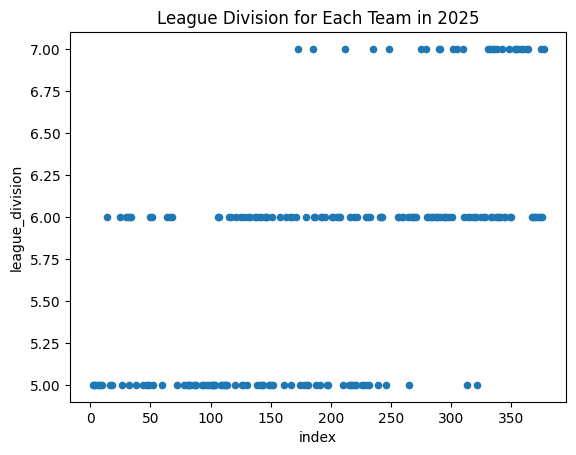

In [25]:
division_25.plot(kind='scatter', x='index', y='league_division', title='League Division for Each Team in 2025')

[02/24/26 10:57:45] INFO     Using categorical units to plot a list of strings that are all         ]8;id=518647;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=602209;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=526712;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/matplotlib/category.py\category.py]8;;\:]8;id=736029;file:///opt/anaconda3/envs/match_prediction/lib/python3.12/site-packages/matplotlib/category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

<Axes: xlabel='index', ylabel='league_division'>

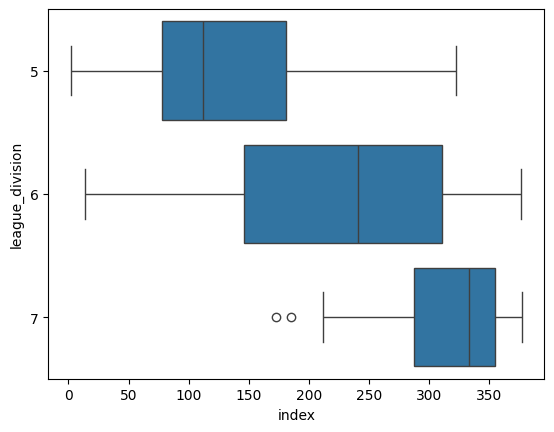

In [26]:
import seaborn as sns
division_25_aux = division_25.copy()
division_25_aux['league_division'] = division_25_aux['league_division'].astype(str)
sns.boxplot(data=division_25_aux, x='index', y='league_division')

In [28]:
division_25[(division_25['index']>150) & (division_25['index']<200)]

,index,league_division
78,151,6
79,152,5
80,158,6
81,161,5
82,163,6
83,166,6
84,167,5
85,168,6
86,171,6
87,173,7


In [35]:
division_25[division_25.league_division==7].head()

,index,league_division
87,173,7
93,185,7
109,212,7
125,235,7
131,248,7


In [36]:
display(ratings_df.loc[173])
display(ratings_df.loc[185])
display(ratings_df.loc[212])
display(ratings_df.loc[235])
display(ratings_df.loc[248])

team                      Valtti/TDJ
attack_rating               1.793642
defense_rating              1.542583
goal_difference_rating      0.251059
Name: 173, dtype: object

team                      MLHF/Reserves
attack_rating                   2.11761
defense_rating                 2.042139
goal_difference_rating         0.075471
Name: 185, dtype: object

team                      HPS/Rangers
attack_rating                1.733522
defense_rating                1.99844
goal_difference_rating      -0.264918
Name: 212, dtype: object

team                      Trikiinit
attack_rating              2.013271
defense_rating              2.48679
goal_difference_rating    -0.473519
Name: 235, dtype: object

team                      FC Lähiö
attack_rating             1.821078
defense_rating            2.446083
goal_difference_rating   -0.625005
Name: 248, dtype: object

In [31]:
df[(df.team_home=='Valtti/TDJ') | (df.team_away=='Valtti/TDJ')]

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
7881,FC POHU/Kova Kamppi,Valtti/TDJ,2,5,7,25,2,2025-06-01
7890,Valtti/TDJ,Käpylän Sekunda,2,3,7,25,2,2025-06-01
7892,Valtti/TDJ,HPS/Rangers,3,0,7,25,2,2025-06-01
7903,ToTe/Arabia,Valtti/TDJ,1,5,7,25,2,2025-06-01
7905,Ponnistus/TK,Valtti/TDJ,1,4,7,25,2,2025-06-01
7907,Valtti/TDJ,FC Pakila,4,0,7,25,2,2025-06-01
7913,Tavastia/FC Mojo,Valtti/TDJ,1,2,7,25,2,2025-06-01
7916,Valtti/TDJ,Kullervo/Überkleber,3,2,7,25,2,2025-06-01
7924,FC Lähiö,Valtti/TDJ,1,1,7,25,2,2025-06-01
7965,Trikiinit,Valtti/TDJ,1,4,7,25,4,2025-06-01


In [33]:
df[(df.team_home=='MLHF/Reserves') | (df.team_away=='MLHF/Reserves')]

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
7931,KOPSE/CRPS FC,MLHF/Reserves,2,2,7,25,3,2025-06-01
7933,MLHF/Reserves,JJ Vepo,6,1,7,25,3,2025-06-01
7939,PK-35/Äijät,MLHF/Reserves,1,1,7,25,3,2025-06-01
7943,MLHF/Reserves,AC StaSi/Europort,8,0,7,25,3,2025-06-01
7944,Valtti/4,MLHF/Reserves,1,1,7,25,3,2025-06-01
7948,MLHF/Reserves,AFC EMU,3,2,7,25,3,2025-06-01
7956,LPS/7,MLHF/Reserves,0,0,7,25,3,2025-06-01
7958,MLHF/Reserves,HeKuLa,5,0,7,25,3,2025-06-01
7962,MLHF/Reserves,Valtti/4,2,1,7,25,4,2025-06-01
7972,Cosmos,MLHF/Reserves,1,7,7,25,4,2025-06-01


In [37]:
df[(df.team_home=='HPS/Rangers') | (df.team_away=='HPS/Rangers')]

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
7883,Kullervo/Überkleber,HPS/Rangers,0,5,7,25,2,2025-06-01
7888,HPS/Rangers,Ponnistus/TK,2,2,7,25,2,2025-06-01
7892,Valtti/TDJ,HPS/Rangers,3,0,7,25,2,2025-06-01
7897,FC POHU/Kova Kamppi,HPS/Rangers,1,3,7,25,2,2025-06-01
7901,HPS/Rangers,Käpylän Sekunda,3,3,7,25,2,2025-06-01
7908,HPS/Rangers,Tavastia/FC Mojo,1,4,7,25,2,2025-06-01
7912,FC Pakila,HPS/Rangers,1,6,7,25,2,2025-06-01
7920,HPS/Rangers,FC Lähiö,1,2,7,25,2,2025-06-01
7925,ToTe/Arabia,HPS/Rangers,1,3,7,25,2,2025-06-01
7998,LPS/7,HPS/Rangers,0,1,7,25,5,2025-06-01


In [32]:
df[((df.team_home=='Trikiinit') | (df.team_away=='Trikiinit')) & (df.season==25)]

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
7846,Trikiinit,Cosmos,2,1,7,25,1,2025-06-01
7849,Kullervo,Trikiinit,1,5,7,25,1,2025-06-01
7855,Trikiinit,MoPo,4,1,7,25,1,2025-06-01
7858,Kilo IF/2,Trikiinit,4,6,7,25,1,2025-06-01
7864,Trikiinit,FC POHU/Sober,5,0,7,25,1,2025-06-01
7867,FC Puimur,Trikiinit,1,3,7,25,1,2025-06-01
7874,Kasiysi/3,Trikiinit,1,3,7,25,1,2025-06-01
7880,Trikiinit,OT-77,6,0,7,25,1,2025-06-01
7963,Käpylän Sekunda,Trikiinit,1,3,7,25,4,2025-06-01
7965,Trikiinit,Valtti/TDJ,1,4,7,25,4,2025-06-01


In [38]:
df[(df.team_home=='FC Lähiö') | (df.team_away=='FC Lähiö')]

,team_home,team_away,goals_home,goals_away,league_division,season,group,date
7885,FC Lähiö,Tavastia/FC Mojo,3,1,7,25,2,2025-06-01
7887,ToTe/Arabia,FC Lähiö,3,4,7,25,2,2025-06-01
7894,Ponnistus/TK,FC Lähiö,0,3,7,25,2,2025-06-01
7900,FC Lähiö,Käpylän Sekunda,4,1,7,25,2,2025-06-01
7902,FC Lähiö,FC POHU/Kova Kamppi,1,3,7,25,2,2025-06-01
...,...,...,...,...,...,...,...,...
8840,FC Lähiö,Valtti/3,6,0,7,20,5,2020-06-01
8842,FC Puimur,FC Lähiö,2,3,7,20,5,2020-06-01
8845,FC Lähiö,MoPo,0,0,7,20,5,2020-06-01
8851,FC Lähiö,KOPSE/CRPS FC,1,3,7,20,5,2020-06-01


In [39]:
team_name = 'FC Lähiö'
df[(df['team_home']==team_name) | (df['team_away']==team_name)].groupby(['season'])['league_division'].unique().reset_index().sort_values(by='season')

,season,league_division
0,20,[7]
1,21,[7]
2,22,[7]
3,23,[7]
4,24,[7]
5,25,[7]


## Simulate 2026

### Get fixtures and table

In [44]:
def initialize_webdriver(url):

    # initialize webdriver
    driver = webdriver.Chrome()
    # load the website
    driver.get(url)

    return driver

In [49]:
def scroll_page(driver):

    # Scroll down repeatedly (to load more content)
    last_height = driver.execute_script("return document.body.scrollHeight")
    while True:
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)  # Wait for loading

        new_height = driver.execute_script("return document.body.scrollHeight")
        if new_height == last_height:
            break  # No more content to load
        last_height = new_height

In [56]:
def get_fixtures(driver):
    
    # get teams
    elements = driver.find_elements(By.CLASS_NAME, 'teamname')
    teams = [elem.text for elem in elements]

    # re-create fixtures
    fixtures = pd.DataFrame(columns=['Home', 'Away'])
    fixtures.Home = teams[0::2]
    fixtures.Away = teams[1::2]
    
    driver.quit()

    return fixtures

In [57]:
def get_table(driver):

    # get teams
    elements = driver.find_elements(By.CLASS_NAME, 'text-start')
    teams = [elem.text for elem in elements]
    teams = teams[7::5]

    # get stats
    elements = driver.find_elements(By.CLASS_NAME, 'text-center')
    stats = [elem.text for elem in elements]
    stats = stats[6::]

    table = pd.DataFrame(columns=['Rk', 'Squad', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts'])
    table.Rk = np.arange(1, len(teams)+1)
    table.Squad = teams
    table.MP = stats[0::6]
    table.W = stats[1::6]
    table.D = stats[2::6]
    table.L = stats[3::6]
    table.GF = [x.split('–')[0] for x in stats[4::6]]
    table.GA = [x.split('–')[1] for x in stats[4::6]]
    table.GD = table['GF'].astype(int) - table['GA'].astype(int)
    table.Pts = stats[5::6]

    # convert to numeric
    table[['Rk', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']] = (
        table[['Rk', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']].apply(pd.to_numeric, errors='coerce')
    )

    driver.quit()

    return table

In [65]:
from selenium import webdriver
from selenium.webdriver.common.by import By
import time
import logging

In [59]:
my_group = 8
driver = initialize_webdriver(f'https://tulospalvelu.palloliitto.fi/category/M6!etejp26/group/{my_group}/fixtures')
scroll_page(driver)

In [60]:
fixtures = get_fixtures(driver)
fixtures

,Home,Away
0,Ruila,Scorpions
1,Ariana FC,Millbrook FC
2,PK-35/Legendat,MK United/Warriors
3,FC Viikingit/S.C.P L,VAMOL/Myyrmäki
4,8/10,Trikiinit
...,...,...
85,VAMOL/Myyrmäki,Ruila
86,Scorpions,Ariana FC
87,Millbrook FC,Trikiinit
88,PK-35/Legendat,FC Viikingit/S.C.P L


In [97]:
fixtures = fixtures.rename(columns={'Home': 'home_team', 'Away': 'away_team'})
fixtures

,home_team,away_team
0,Ruila,Scorpions
1,Ariana FC,Millbrook FC
2,PK-35/Legendat,MK United/Warriors
3,FC Viikingit/S.C.P L,VAMOL/Myyrmäki
4,8/10,Trikiinit
...,...,...
85,VAMOL/Myyrmäki,Ruila
86,Scorpions,Ariana FC
87,Millbrook FC,Trikiinit
88,PK-35/Legendat,FC Viikingit/S.C.P L


In [61]:
driver = initialize_webdriver(f'https://tulospalvelu.palloliitto.fi/category/M6!etejp26/group/{my_group}/')

In [62]:
table = get_table(driver)
table

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts
0,1,8/10,0,0,0,0,0,0,0,0
1,2,Ariana FC,0,0,0,0,0,0,0,0
2,3,FC Viikingit/S.C.P L,0,0,0,0,0,0,0,0
3,4,MK United/Warriors,0,0,0,0,0,0,0,0
4,5,Millbrook FC,0,0,0,0,0,0,0,0
5,6,PK-35/Legendat,0,0,0,0,0,0,0,0
6,7,Ruila,0,0,0,0,0,0,0,0
7,8,Scorpions,0,0,0,0,0,0,0,0
8,9,Trikiinit,0,0,0,0,0,0,0,0
9,10,VAMOL/Myyrmäki,0,0,0,0,0,0,0,0


### Simulate league

In [109]:
from tqdm import tqdm
from types import SimpleNamespace

In [101]:
import sys
sys.path.insert(0, '../src')
from utils import simulate_match, update_league_table
from dixon_coles import process_simulation_results

In [93]:
def simulate_league(clf, league_table, fixtures, nr_simulations, new_teams, substitute_teams):
    """
    Simulate the season using the fitted model.
    """

    logging.info("Starting to run simulations...")
    rng = np.random.default_rng()  
    simulation_results = []
    for i in tqdm(range(nr_simulations), desc='Simulating...'):
        simulated_table = league_table[['Rk', 'Squad', 'MP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']].copy()
        selected_teams = rng.choice(substitute_teams, size=4, replace=False)
        for i in range(len(selected_teams)):
            my_helper_dict[new_teams[i]] = selected_teams[i]
        simulated_table = simulate_season(simulated_table, fixtures, clf, my_helper_dict)
        simulated_table['simulation_nr'] = i
        simulation_results.append(simulated_table)

    logging.info("Simulations finished.")
    simulation_results_df = pd.concat(simulation_results).reset_index(drop=True)
    return simulation_results_df

In [94]:
def simulate_season(league_table, fixtures, clf, my_helper_dict):
    '''Simulate a whole season.'''
    
    for _, fixture in fixtures.iterrows():
        home_team_ = fixture.home_team
        away_team_ = fixture.away_team
        # simulate match outcome
        outcome, home_goals, away_goals = simulate_match(clf, my_helper_dict[home_team_], my_helper_dict[away_team_])
        update_league_table(league_table, home_team_, away_team_, outcome, home_goals, away_goals, fixture)
    
    assert len(np.unique(league_table['MP'])) == 1, 'Not all teams have played the same number of matches!'

    league_table = league_table.sort_values(by=['Pts', 'GD', 'GF'], ascending=False)
    league_table['Rk'] = np.arange(1,league_table.shape[0]+1)

    return league_table

In [82]:
new_teams = ['8/10', 'Ariana FC', 'Scorpions', 'VAMOL/Myyrmäki']

# use these teams to substitute randomly for new teams
substitute_teams = new_team_ratings_df.team.unique()
substitute_teams


array(['FC POHU/CJ United', 'Mando United', 'Helsinki Stars',
       'PPJ/West Wanderers', 'JäPS/Akatemia', 'Sibbo-Vargarna/2',
       'PuiU/Akatemia', 'AFG united', 'FC Kotkat', 'FC Kontu/U23',
       'Tähti Helsinki', 'NJS/2', 'StaKe FC', 'Töölö Tigers', 'Valtti/LA',
       'MK United/Warriors', 'KP-75', 'FC POHU/Traktori', 'Espoon Sonnit',
       'PPJ/Jätkäsaari', 'PEP/Pitkätossut', 'FC POHU/Toivo', 'VJS/3',
       'Kutosen Klopit', 'JäPS/City', 'Mäntsälän Urheilijat', 'DFSV'],
      dtype=object)

In [83]:
my_helper_dict = {
    'Trikiinit': 'Trikiinit',
    'FC Viikingit/S.C.P L': 'FC Viikingit/S.C.P L',
    'MK United/Warriors': 'MK United/Warriors',
    'Millbrook FC': 'Millbrook FC',
    'PK-35/Legendat': 'PK-35/Legendat',
    'Ruila': 'Ruila',
}

In [98]:
simulation_results_df = simulate_league(
    clf, 
    league_table=table, 
    fixtures=fixtures, 
    nr_simulations=1000, 
    new_teams=new_teams, 
    substitute_teams=substitute_teams
    )

[02/24/26 13:07:14] INFO     Starting to run simulations...                                         ]8;id=18129;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=838398;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#6\6]8;;\

Simulating...: 100%|██████████| 1000/1000 [03:57<00:00,  4.21it/s]


[02/24/26 13:11:12] INFO     Simulations finished.                                                 ]8;id=286372;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=70279;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#18\18]8;;\

[02/24/26 13:25:10] INFO     Processing simulation results...                                    ]8;id=158960;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=222926;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#156\156]8;;\

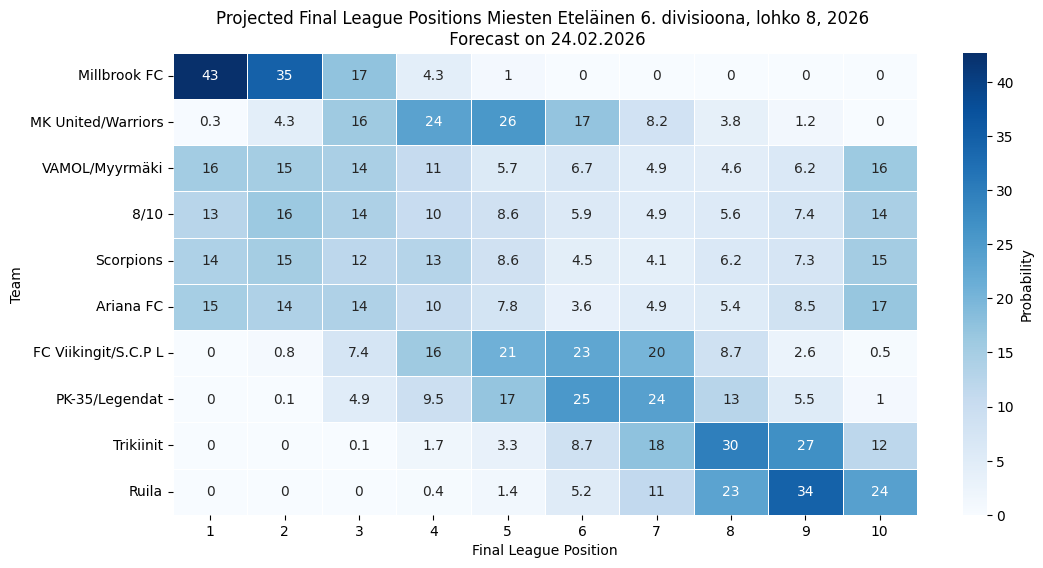

In [111]:
my_args = SimpleNamespace(
    league='Miesten Eteläinen 6. divisioona, lohko 8, 2026',
    save_simulation_results=False,
)

process_simulation_results(simulation_results_df, nr_simulations=1000, args=my_args)

In [112]:
my_helper_dict = {
    'Trikiinit': 'Valtti/TDJ',
    'FC Viikingit/S.C.P L': 'FC Viikingit/S.C.P L',
    'MK United/Warriors': 'MK United/Warriors',
    'Millbrook FC': 'Millbrook FC',
    'PK-35/Legendat': 'PK-35/Legendat',
    'Ruila': 'Ruila',
}

In [113]:
simulation_results_df = simulate_league(
    clf, 
    league_table=table, 
    fixtures=fixtures, 
    nr_simulations=1000, 
    new_teams=new_teams, 
    substitute_teams=substitute_teams
    )

[02/24/26 13:26:18] INFO     Starting to run simulations...                                         ]8;id=790847;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=930306;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#6\6]8;;\

Simulating...: 100%|██████████| 1000/1000 [04:07<00:00,  4.04it/s]


[02/24/26 13:30:26] INFO     Simulations finished.                                                 ]8;id=450112;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=129038;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#18\18]8;;\

[02/24/26 13:32:17] INFO     Processing simulation results...                                    ]8;id=475400;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=418221;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#156\156]8;;\

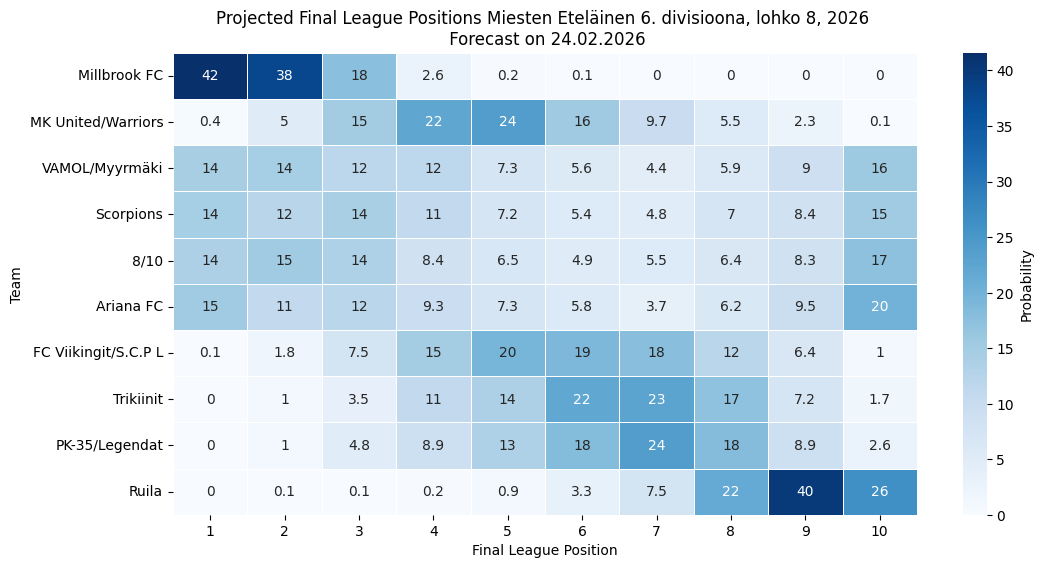

In [114]:
my_args = SimpleNamespace(
    league='Miesten Eteläinen 6. divisioona, lohko 8, 2026',
    save_simulation_results=False,
)

process_simulation_results(simulation_results_df, nr_simulations=1000, args=my_args)

In [115]:
# use these teams to substitute randomly for new teams
new_team_ratings_df.team.unique()

array(['FC POHU/CJ United', 'Mando United', 'Helsinki Stars',
       'PPJ/West Wanderers', 'JäPS/Akatemia', 'Sibbo-Vargarna/2',
       'PuiU/Akatemia', 'AFG united', 'FC Kotkat', 'FC Kontu/U23',
       'Tähti Helsinki', 'NJS/2', 'StaKe FC', 'Töölö Tigers', 'Valtti/LA',
       'MK United/Warriors', 'KP-75', 'FC POHU/Traktori', 'Espoon Sonnit',
       'PPJ/Jätkäsaari', 'PEP/Pitkätossut', 'FC POHU/Toivo', 'VJS/3',
       'Kutosen Klopit', 'JäPS/City', 'Mäntsälän Urheilijat', 'DFSV'],
      dtype=object)

In [116]:
# use these teams to substitute randomly for new teams
substitute_teams = np.array(['NJS/2', 'StaKe FC', 'Töölö Tigers', 'Valtti/LA',
       'MK United/Warriors', 'KP-75', 'FC POHU/Traktori', 'Espoon Sonnit',
       'PPJ/Jätkäsaari', 'PEP/Pitkätossut', 'FC POHU/Toivo', 'VJS/3',
       'Kutosen Klopit', 'JäPS/City', 'Mäntsälän Urheilijat', 'DFSV'])
substitute_teams

array(['NJS/2', 'StaKe FC', 'Töölö Tigers', 'Valtti/LA',
       'MK United/Warriors', 'KP-75', 'FC POHU/Traktori', 'Espoon Sonnit',
       'PPJ/Jätkäsaari', 'PEP/Pitkätossut', 'FC POHU/Toivo', 'VJS/3',
       'Kutosen Klopit', 'JäPS/City', 'Mäntsälän Urheilijat', 'DFSV'],
      dtype='<U20')

In [117]:
simulation_results_df = simulate_league(
    clf, 
    league_table=table, 
    fixtures=fixtures, 
    nr_simulations=1000, 
    new_teams=new_teams, 
    substitute_teams=substitute_teams
    )

[02/24/26 13:38:28] INFO     Starting to run simulations...                                         ]8;id=30789;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=811107;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#6\6]8;;\

Simulating...: 100%|██████████| 1000/1000 [04:07<00:00,  4.03it/s]


[02/24/26 13:42:36] INFO     Simulations finished.                                                 ]8;id=816625;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py\3902926178.py]8;;\:]8;id=825662;file:///var/folders/rk/l4zzc3ps1ll65p_r4_vjhwrw0000gn/T/ipykernel_8150/3902926178.py#18\18]8;;\

[02/24/26 13:42:39] INFO     Processing simulation results...                                    ]8;id=188680;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py\dixon_coles.py]8;;\:]8;id=87318;file:///Users/jaakkotoivonen/repos/match_prediction/notebooks/../src/dixon_coles.py#156\156]8;;\

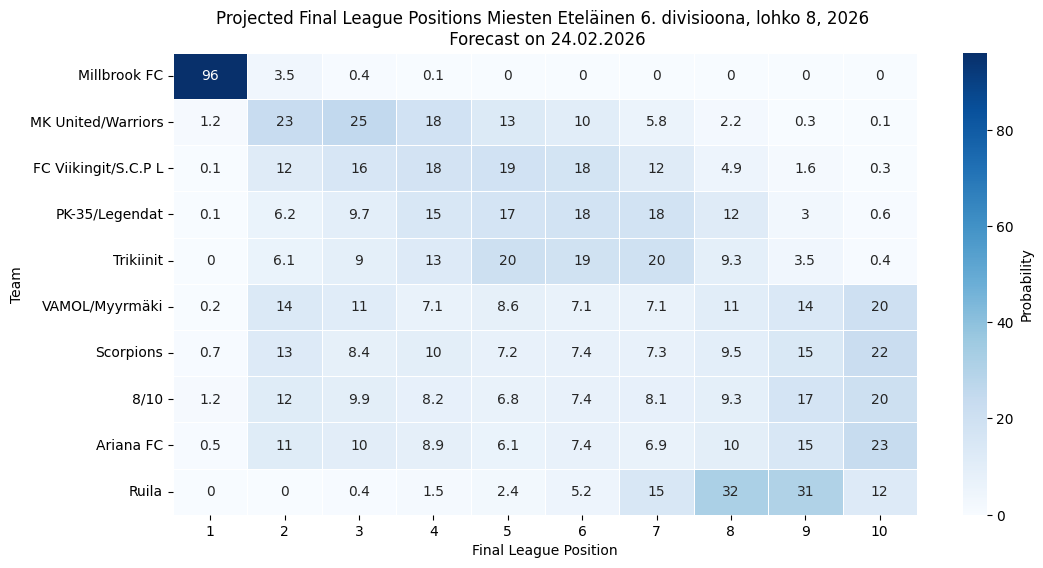

In [118]:
my_args = SimpleNamespace(
    league='Miesten Eteläinen 6. divisioona, lohko 8, 2026',
    save_simulation_results=False,
)

process_simulation_results(simulation_results_df, nr_simulations=1000, args=my_args)

In [123]:
simulation_results_df.groupby('Squad').mean()['Rk'].sort_values()

Squad
Millbrook FC            1.046
MK United/Warriors      3.869
FC Viikingit/S.C.P L    4.792
PK-35/Legendat          5.519
Trikiinit               5.533
VAMOL/Myyrmäki          6.399
Scorpions               6.524
8/10                    6.543
Ariana FC               6.627
Ruila                   8.148
Name: Rk, dtype: float64